In [1]:
import pandas as pd

print("Data loading...")
X_train = pd.read_csv('processed_data/X_train_final.csv')
y_train = pd.read_csv('processed_data/y_train_final.csv')['loan_status']

X_valid = pd.read_csv('processed_data/X_valid_final.csv')
y_valid = pd.read_csv('processed_data/y_valid_final.csv')['loan_status']

X_test = pd.read_csv('processed_data/X_test_final.csv')
y_test = pd.read_csv('processed_data/y_test_final.csv')['loan_status']

print(f"Data size - Train: {X_train.shape}")
print(f"Data size - Valid: {X_valid.shape}")
print(f"Data size - Test: {X_test.shape}")

Data loading...
Data size - Train: (35660, 20)
Data size - Valid: (4887, 20)
Data size - Test: (4888, 20)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

def evaluate_model(model, X_train, y_train, X_eval, y_eval, model_name, fit_model=True, threshold=0.5):
    """
    Hàm này giúp huấn luyện, dự đoán và in ra các chỉ số đánh giá cho mô hình.
    X_eval, y_eval: Có thể là tập Valid (để tinh chỉnh) hoặc tập Test (để thi thật).
    """
    print(f"\n{'='*50}")
    print(f"--- ĐÁNH GIÁ MÔ HÌNH: {model_name} (Threshold: {threshold:.2f}) ---")
    print(f"{'='*50}")
    
    # Training nếu có yêu cầu
    if fit_model:
        model.fit(X_train, y_train)
    
    # Dự đoán trên tập Đánh giá
    y_pred_proba = model.predict_proba(X_eval)[:, 1] # Lấy xác suất rơi vào Nợ xấu (Class 1)
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # Classification Report
    print("\n1. BÁO CÁO PHÂN LOẠI (Classification Report):")
    print(classification_report(y_eval, y_pred, target_names=['Trả đủ (0)', 'Nợ xấu (1)']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Đoán: Trả đủ', 'Đoán: Nợ xấu'],
                yticklabels=['Thật: Trả đủ', 'Thật: Nợ xấu'])
    plt.title(f'Ma trận nhầm lẫn - {model_name}')
    plt.ylabel('Thực tế')
    plt.xlabel('Mô hình Dự đoán')
    plt.show()
    
    # Tính ROC-AUC
    auc_score = roc_auc_score(y_eval, y_pred_proba)
    print(f"\n=> ĐIỂM ROC-AUC: {auc_score:.4f}")
    print(f"=> Threshold: {threshold:.2f}")
    return y_pred_proba, auc_score


--- ĐÁNH GIÁ MÔ HÌNH: Logistic Regression (Threshold: 0.50) ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.92      0.83      0.88      3821
  Nợ xấu (1)       0.56      0.75      0.64      1066

    accuracy                           0.82      4887
   macro avg       0.74      0.79      0.76      4887
weighted avg       0.84      0.82      0.82      4887



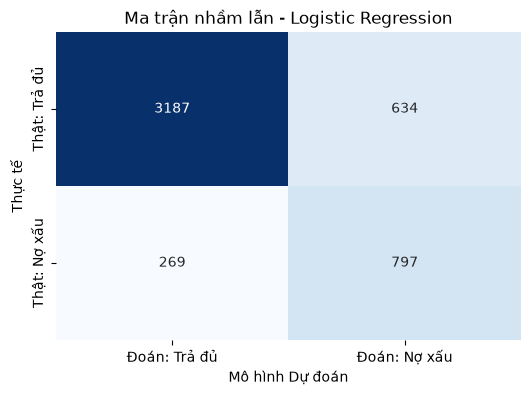


=> ĐIỂM ROC-AUC: 0.8633
=> Threshold: 0.50


In [3]:
# LOGISTIC REGRESSION (BASELINE)
from sklearn.linear_model import LogisticRegression
# Khởi tạo (Tăng max_iter để đảm bảo thuật toán hội tụ)
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# đánh giá
proba_logreg, auc_logreg = evaluate_model(
    model=log_reg, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_valid, y_eval=y_valid, 
    model_name="Logistic Regression"
)


--- ĐÁNH GIÁ MÔ HÌNH: XGBoost Classifier (Tập Validation) (Threshold: 0.50) ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.92      0.98      0.95      3821
  Nợ xấu (1)       0.91      0.71      0.80      1066

    accuracy                           0.92      4887
   macro avg       0.92      0.84      0.87      4887
weighted avg       0.92      0.92      0.92      4887



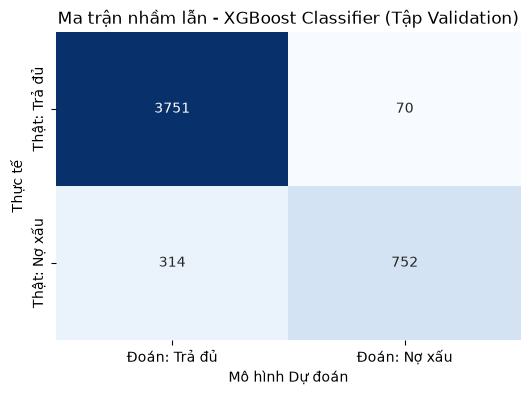


=> ĐIỂM ROC-AUC: 0.9337
=> Threshold: 0.50


In [4]:
# XGBOOST (NÂNG CAO)
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,      # Số lượng cây quyết định
    learning_rate=0.1,     # Tốc độ học
    max_depth=5,           # Độ sâu tối đa của cây (tránh overfitting)
    random_state=42,
    eval_metric='logloss'  # Hàm mất mát cho bài toán phân loại
)

# Gọi hàm đánh giá trên tập Validation
proba_xgb, auc_xgb = evaluate_model(
    model=xgb_model, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_valid, y_eval=y_valid, 
    model_name="XGBoost Classifier (Tập Validation)"
)


--- SO SÁNH TỔNG THỂ HAI THUẬT TOÁN (TẬP VALIDATION) ---


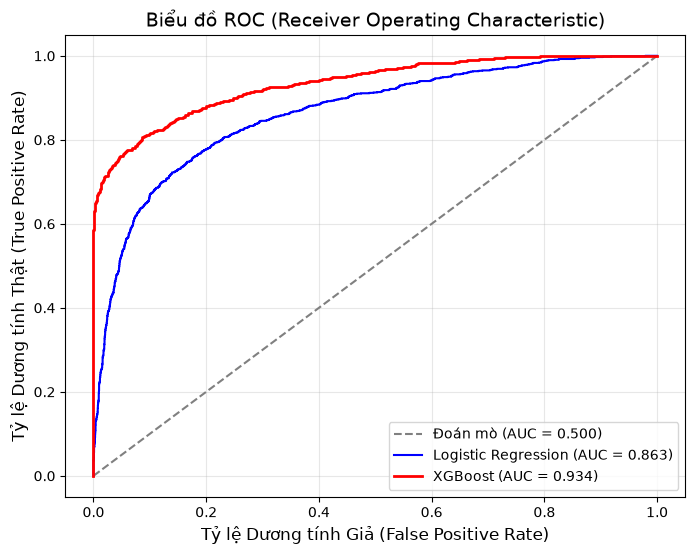

In [5]:
import matplotlib.pyplot as plt
print("\n--- SO SÁNH TỔNG THỂ HAI THUẬT TOÁN (TẬP VALIDATION) ---")

# Tính toán các điểm trên đường cong ROC cho cả 2 mô hình
fpr_logreg, tpr_logreg, _ = roc_curve(y_valid, proba_logreg)
fpr_xgb, tpr_xgb, _ = roc_curve(y_valid, proba_xgb)

plt.figure(figsize=(8, 6))
# Vẽ đường Baseline ngẫu nhiên (50/50)
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Đoán mò (AUC = 0.500)')

# Vẽ đường Logistic Regression
plt.plot(fpr_logreg, tpr_logreg, color='blue', 
         label=f'Logistic Regression (AUC = {auc_logreg:.3f})')

# Vẽ đường XGBoost
plt.plot(fpr_xgb, tpr_xgb, color='red', linewidth=2,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')

plt.title('Biểu đồ ROC (Receiver Operating Characteristic)', fontsize=14)
plt.xlabel('Tỷ lệ Dương tính Giả (False Positive Rate)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính Thật (True Positive Rate)', fontsize=12)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

--- TÌM NGƯỠNG TỐI ƯU DỰA TRÊN KPI NGHIỆP VỤ (CONSTRAINT-BASED) ---
Ngưỡng KPI (Recall >= 80%) của Logistic Regression : 0.4175
Ngưỡng KPI (Recall >= 80%) của XGBoost           : 0.2554

--- ĐÁNH GIÁ MÔ HÌNH: Logistic Regression (Đã Tuning Ngưỡng) (Threshold: 0.42) ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.93      0.77      0.84      3821
  Nợ xấu (1)       0.49      0.80      0.61      1066

    accuracy                           0.78      4887
   macro avg       0.71      0.79      0.73      4887
weighted avg       0.84      0.78      0.79      4887



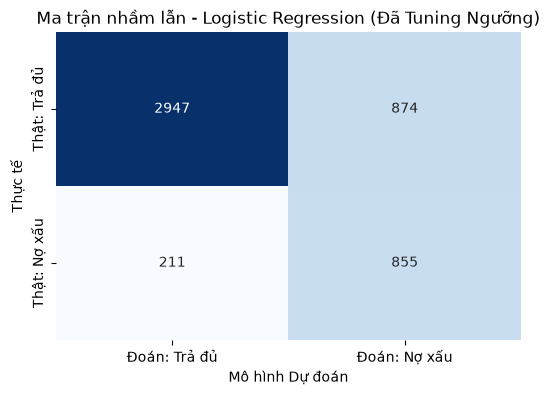


=> ĐIỂM ROC-AUC: 0.8633
=> Threshold: 0.42

--- ĐÁNH GIÁ MÔ HÌNH: XGBoost (Đã Tuning Ngưỡng) (Threshold: 0.26) ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.94      0.92      0.93      3821
  Nợ xấu (1)       0.73      0.80      0.76      1066

    accuracy                           0.89      4887
   macro avg       0.83      0.86      0.85      4887
weighted avg       0.90      0.89      0.89      4887



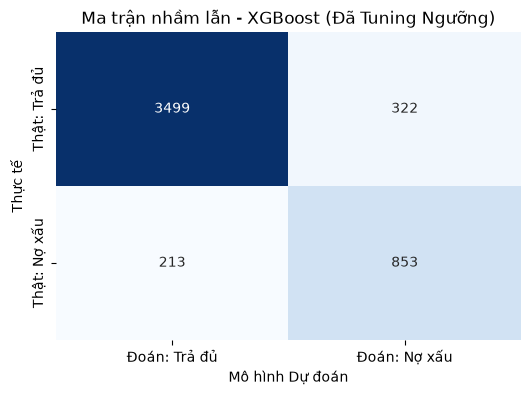


=> ĐIỂM ROC-AUC: 0.9337
=> Threshold: 0.26


In [7]:
from sklearn.metrics import precision_recall_curve

# print("\n--- TUNING THRESHOLD XGBOOST TẬP VALIDATION VỚI RECALL>=80%---")

# precisions, recalls, thresholds = precision_recall_curve(y_valid, proba_xgb)
# target_recall = 0.8  # Mục tiêu Recall tối thiểu   
# # 1. Lọc ra danh sách các vị trí mà Recall đạt được tối thiểu mục tiêu (>= 80%)
# valid_indices = np.where(recalls >= target_recall)[0]

# # 2. Trong các vị trí thỏa mãn Recall >= 80%, chọn nơi có Precision cao nhất
# best_index = valid_indices[np.argmax(precisions[valid_indices])]

# # Do hàm precision_recall_curve trả về len(thresholds) = len(precisions) - 1
# # Nên cần xử lý ngoại lệ nếu best_index nằm ở cuối cùng
# if best_index == len(thresholds):
#     best_index -= 1
    
# best_threshold = thresholds[best_index]
# print(f"-> Đã tìm thấy Ngưỡng cắt tối ưu: {best_threshold:.4f}")

# # 2. Đánh giá lại XGBoost với Threshold Mới (KHÔNG cần fit lại mô hình)
# # Ở đây ta gọi lại hàm evaluate_model, truyền vào best_threshold và fit_model=False
# _, _ = evaluate_model(
#     model=xgb_model, 
#     X_train=X_train, y_train=y_train, 
#     X_eval=X_valid, y_eval=y_valid, 
#     model_name="XGBoost (Đã Tuning Ngưỡng)", 
#     fit_model=False, 
#     threshold=best_threshold  # <--- Truyền ngưỡng mới vào đây
# )
print("--- TÌM NGƯỠNG TỐI ƯU DỰA TRÊN KPI NGHIỆP VỤ (CONSTRAINT-BASED) ---")

def find_threshold_by_target_recall(y_true, y_proba, target_recall=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    
    # 1. Lọc ra danh sách các vị trí mà Recall đạt được tối thiểu mục tiêu (>= 80%)
    valid_indices = np.where(recalls >= target_recall)[0]
    
    if len(valid_indices) == 0:
        print("Cảnh báo: Không có ngưỡng nào đạt được Recall mục tiêu!")
        return 0.5 # Trả về mặc định nếu thất bại
        
    # 2. Trong các vị trí thỏa mãn Recall >= 80%, chọn nơi có Precision cao nhất
    best_index = valid_indices[np.argmax(precisions[valid_indices])]
    
    # Do hàm precision_recall_curve trả về len(thresholds) = len(precisions) - 1
    # Nên cần xử lý ngoại lệ nếu best_index nằm ở cuối cùng
    if best_index == len(thresholds):
        best_index -= 1
        
    return thresholds[best_index]

# Tìm ngưỡng dựa trên KPI: Ép Recall tối thiểu đạt 80% (0.80)
# Đối với Logistic, có thể nó không bao giờ đạt được tỷ lệ đẹp, nhưng cứ áp dụng để so sánh
best_thresh_logreg = find_threshold_by_target_recall(y_valid, proba_logreg, target_recall=0.80)
best_thresh_xgb = find_threshold_by_target_recall(y_valid, proba_xgb, target_recall=0.80)

print(f"Ngưỡng KPI (Recall >= 80%) của Logistic Regression : {best_thresh_logreg:.4f}")
print(f"Ngưỡng KPI (Recall >= 80%) của XGBoost           : {best_thresh_xgb:.4f}")

_, _ = evaluate_model(
    model=log_reg, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_valid, y_eval=y_valid, 
    model_name="Logistic Regression (Đã Tuning Ngưỡng)", 
    fit_model=False, 
    threshold=best_thresh_logreg  # <--- Truyền ngưỡng mới vào đây
)
_, _ = evaluate_model(
    model=xgb_model, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_valid, y_eval=y_valid, 
    model_name="XGBoost (Đã Tuning Ngưỡng)", 
    fit_model=False, 
    threshold=best_thresh_xgb  # <--- Truyền ngưỡng mới vào đây
)


--- KIỂM TRA TRÊN TẬP TEST ---
Sau khi đối chiếu 2 models, XGBoost là model hiệu quả hơn.

--- ĐÁNH GIÁ MÔ HÌNH: XGBoost Classifier (Threshold: 0.26) ---

1. BÁO CÁO PHÂN LOẠI (Classification Report):
              precision    recall  f1-score   support

  Trả đủ (0)       0.94      0.92      0.93      3822
  Nợ xấu (1)       0.73      0.78      0.75      1066

    accuracy                           0.89      4888
   macro avg       0.83      0.85      0.84      4888
weighted avg       0.89      0.89      0.89      4888



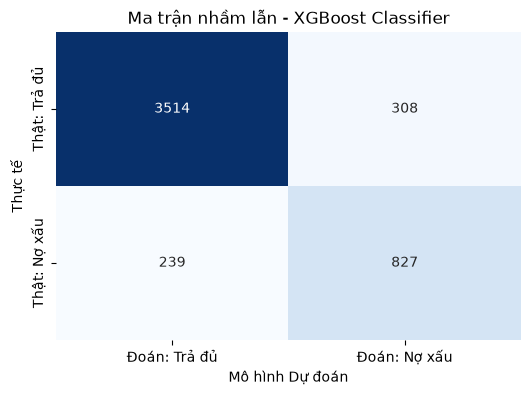


=> ĐIỂM ROC-AUC: 0.9248
=> Threshold: 0.26


In [8]:
# ĐÁNH GIÁ TRÊN TẬP TEST (BÀI THI CUỐI CÙNG)
print("\n" + "="*50)
print("--- KIỂM TRA TRÊN TẬP TEST ---")
print("="*50)
print("Sau khi đối chiếu 2 models, XGBoost là model hiệu quả hơn.")

# Đánh giá lại mô hình XGBoost trên tập Test
proba_test_xgb, auc_test_xgb = evaluate_model(
    model=xgb_model, 
    X_train=X_train, y_train=y_train, 
    X_eval=X_test, y_eval=y_test, 
    model_name="XGBoost Classifier",
    fit_model=False, # Tắt chế độ fit để giữ nguyên trọng số đã học
    threshold=best_thresh_xgb  # Sử dụng ngưỡng đã tìm được từ tập Validation
)

--- TỔNG HỢP, TRỰC QUAN HÓA VÀ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ---


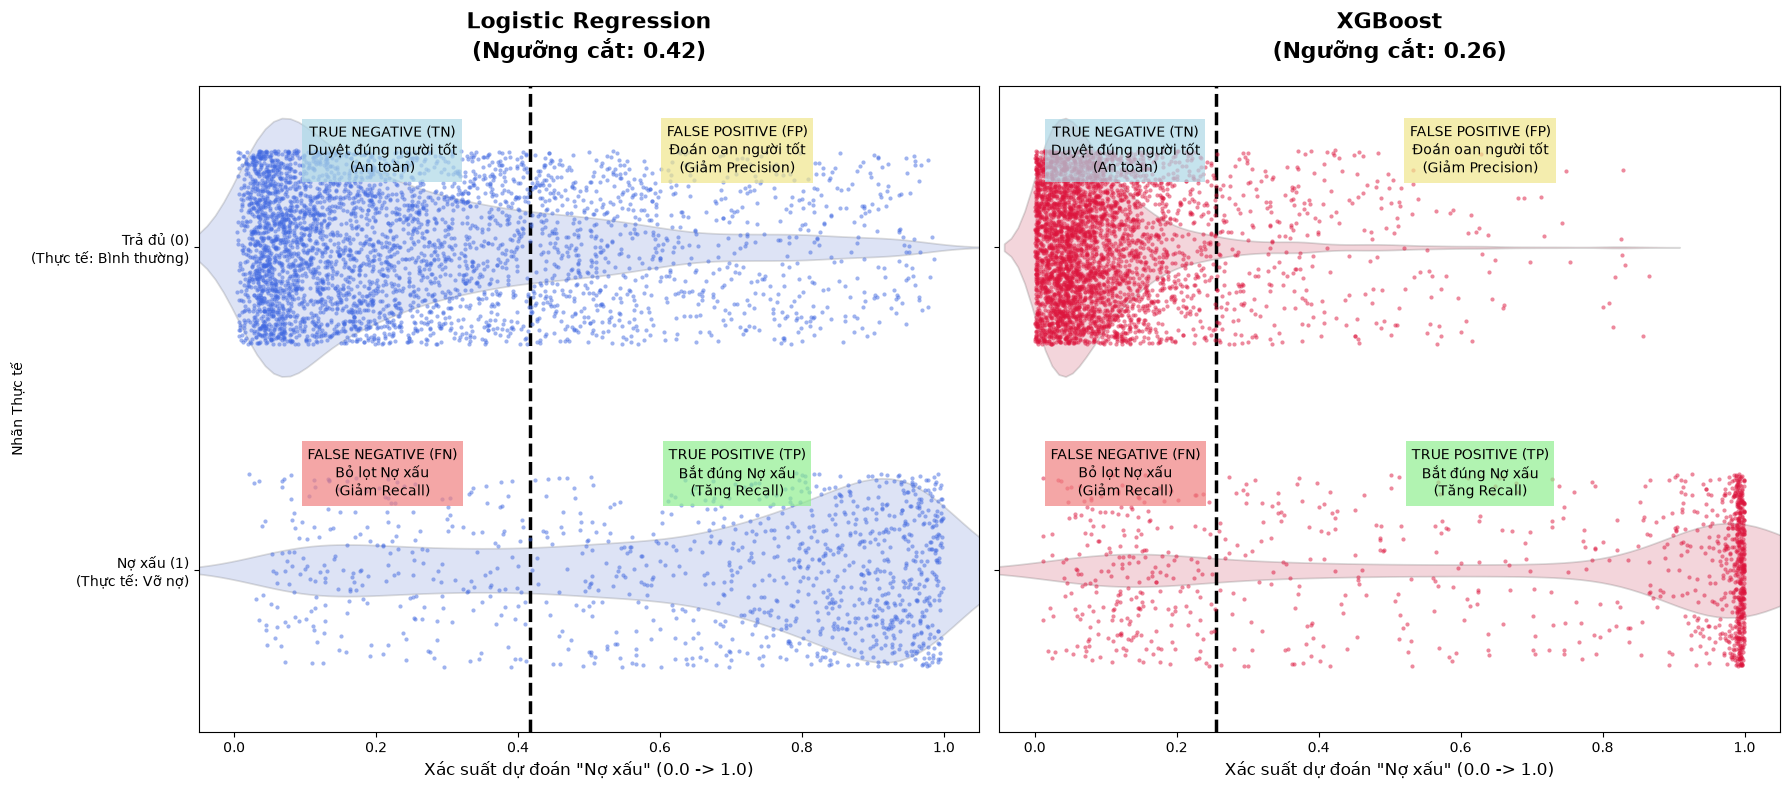


BẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ THỰC TẾ TRÊN TẬP TEST:



,Thuật toán,Accuracy,Precision (Nợ xấu),Recall (Nợ xấu),F1-Score,ROC-AUC
0,Logistic Regression (Ngưỡng 0.42),77.52%,49.03%,77.95%,0.6020,0.8546
1,XGBoost Classifier (Ngưỡng 0.26),88.81%,72.86%,77.58%,0.7515,0.9248


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve
from IPython.display import display

print("=====================================================================")
print("--- TỔNG HỢP, TRỰC QUAN HÓA VÀ ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST ---")
print("=====================================================================")

# -------------------------------------------------------------------------
# BƯỚC 0: TÌM LẠI NGƯỠNG TỐI ƯU TỪ TẬP VALID (KPI: Recall >= 80%)
# (Đưa hàm này vào đây để đảm bảo code chạy độc lập và không bị lỗi thiếu biến)
# -------------------------------------------------------------------------
def get_kpi_threshold(y_true, y_proba, target=0.80):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_proba)
    valid_idx = np.where(recalls >= target)[0]
    if len(valid_idx) == 0: return 0.5
    best_idx = valid_idx[np.argmax(precisions[valid_idx])]
    return thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]

proba_valid_logreg = log_reg.predict_proba(X_valid)[:, 1]
proba_valid_xgb = xgb_model.predict_proba(X_valid)[:, 1]

best_thresh_logreg = get_kpi_threshold(y_valid, proba_valid_logreg, 0.80)
best_thresh_xgb = get_kpi_threshold(y_valid, proba_valid_xgb, 0.80)

# -------------------------------------------------------------------------
# BƯỚC 1: LẤY XÁC SUẤT VÀ TẠO NHÃN TRÊN TẬP TEST (VỚI NGƯỠNG TỐI ƯU)
# -------------------------------------------------------------------------
proba_test_logreg = log_reg.predict_proba(X_test)[:, 1]
proba_test_xgb = xgb_model.predict_proba(X_test)[:, 1]

y_test_bin = np.array(y_test).astype(int)

# TỰ ĐỘNG CHUYỂN ĐỔI XÁC SUẤT THÀNH NHÃN BẰNG NGƯỠNG VỪA TÌM ĐƯỢC
y_pred_logreg_bin = (proba_test_logreg >= best_thresh_logreg).astype(int)
y_pred_xgb_bin = (proba_test_xgb >= best_thresh_xgb).astype(int)

# -------------------------------------------------------------------------
# BƯỚC 2: TẠO BẢNG DỮ LIỆU VÀ VẼ BIỂU ĐỒ NẰM NGANG
# -------------------------------------------------------------------------
df_results = pd.DataFrame({
    'Thực tế': y_test_bin,
    'Logistic Regression': proba_test_logreg,
    'XGBoost': proba_test_xgb
})

df_results['Nhãn Thực tế'] = df_results['Thực tế'].map({0: 'Trả đủ (0)\n(Thực tế: Bình thường)', 
                                                        1: 'Nợ xấu (1)\n(Thực tế: Vỡ nợ)'})

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)

models = ['Logistic Regression', 'XGBoost']
colors = ['royalblue', 'crimson']
thresholds_list = [best_thresh_logreg, best_thresh_xgb]

for i, model in enumerate(models):
    current_thresh = thresholds_list[i]
    
    # Lớp nền Violin và Lớp điểm Strip
    sns.violinplot(data=df_results, x=model, y='Nhãn Thực tế', 
                   inner=None, color=colors[i], alpha=0.2, ax=axes[i], orient='h')
    sns.stripplot(data=df_results, x=model, y='Nhãn Thực tế', 
                  color=colors[i], alpha=0.5, size=3, jitter=0.3, ax=axes[i], orient='h')
    
    # Vẽ vạch ranh giới quyết định THEO NGƯỠNG MỚI
    axes[i].axvline(current_thresh, color='black', linestyle='--', linewidth=2.5)
    
    # Định dạng trục
    axes[i].set_title(f'{model}\n(Ngưỡng cắt: {current_thresh:.2f})', fontsize=16, fontweight='bold', pad=20)
    axes[i].set_xlabel('Xác suất dự đoán "Nợ xấu" (0.0 -> 1.0)', fontsize=12)
    axes[i].set_xlim(-0.05, 1.05)
    
    # --- TÍNH TOÁN TỌA ĐỘ ĐỘNG CHO CÁC HỘP CHÚ THÍCH ---
    # Canh giữa phần bên trái ranh giới
    left_x = current_thresh / 2  
    # Canh giữa phần bên phải ranh giới
    right_x = current_thresh + (1.0 - current_thresh) / 2  
    
    # Góc phải trên (TP)
    axes[i].text(right_x, 0.7, 'TRUE POSITIVE (TP)\nBắt đúng Nợ xấu\n(Tăng Recall)', 
                 ha='center', va='center', bbox=dict(facecolor='lightgreen', alpha=0.7, edgecolor='none'))
    # Góc trái trên (FN)
    axes[i].text(left_x, 0.7, 'FALSE NEGATIVE (FN)\nBỏ lọt Nợ xấu\n(Giảm Recall)', 
                 ha='center', va='center', bbox=dict(facecolor='lightcoral', alpha=0.7, edgecolor='none'))
    # Góc phải dưới (FP)
    axes[i].text(right_x, -0.3, 'FALSE POSITIVE (FP)\nĐoán oan người tốt\n(Giảm Precision)', 
                 ha='center', va='center', bbox=dict(facecolor='khaki', alpha=0.7, edgecolor='none'))
    # Góc trái dưới (TN)
    axes[i].text(left_x, -0.3, 'TRUE NEGATIVE (TN)\nDuyệt đúng người tốt\n(An toàn)', 
                 ha='center', va='center', bbox=dict(facecolor='lightblue', alpha=0.7, edgecolor='none'))

plt.ylabel('')
plt.tight_layout()
plt.show()

# -------------------------------------------------------------------------
# BƯỚC 3: IN BẢNG BÁO CÁO THỐNG KÊ (ĐÃ CẬP NHẬT NGƯỠNG)
# -------------------------------------------------------------------------
metrics_logreg = {
    "Thuật toán": f"Logistic Regression (Ngưỡng {best_thresh_logreg:.2f})",
    "Accuracy": f"{accuracy_score(y_test_bin, y_pred_logreg_bin):.2%}",
    "Precision (Nợ xấu)": f"{precision_score(y_test_bin, y_pred_logreg_bin):.2%}",
    "Recall (Nợ xấu)": f"{recall_score(y_test_bin, y_pred_logreg_bin):.2%}",
    "F1-Score": f"{f1_score(y_test_bin, y_pred_logreg_bin):.4f}",
    "ROC-AUC": f"{roc_auc_score(y_test_bin, proba_test_logreg):.4f}"
}

metrics_xgb = {
    "Thuật toán": f"XGBoost Classifier (Ngưỡng {best_thresh_xgb:.2f})",
    "Accuracy": f"{accuracy_score(y_test_bin, y_pred_xgb_bin):.2%}",
    "Precision (Nợ xấu)": f"{precision_score(y_test_bin, y_pred_xgb_bin):.2%}",
    "Recall (Nợ xấu)": f"{recall_score(y_test_bin, y_pred_xgb_bin):.2%}",
    "F1-Score": f"{f1_score(y_test_bin, y_pred_xgb_bin):.4f}",
    "ROC-AUC": f"{roc_auc_score(y_test_bin, proba_test_xgb):.4f}"
}

df_report = pd.DataFrame([metrics_logreg, metrics_xgb])

print("\nBẢNG TỔNG HỢP CHỈ SỐ ĐÁNH GIÁ THỰC TẾ TRÊN TẬP TEST:\n")
display(df_report)